## Histogram

1. Подключение к db.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


conn = sqlite3.connect("../data/checking-logs.sqlite")

2. SQL-запрос и формирование lists.

In [2]:
query_commits = """
SELECT timestamp
FROM checker
WHERE uid NOT LIKE "admin%"
"""

df = pd.read_sql(query_commits, conn)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["day_of_week"] = df["timestamp"].dt.day_name()
df["hour"] = df["timestamp"].dt.hour
df["weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

working_days_list = list(df[df['weekend'] == False]['hour'])
weekends_list = list(df[df['weekend'] == True]['hour'])

print(f"Длина списка рабочих дней: {len(working_days_list)}\nДлина списка выходных дней: {len(weekends_list)}")

Длина списка рабочих дней: 2037
Длина списка выходных дней: 1170


3. Формирование датафрейма.

In [3]:
working_days = df[df['weekend'] == False]['hour'].value_counts().sort_index()
weekends = df[df['weekend'] == True]['hour'].value_counts().sort_index()

working_days = working_days.reindex(range(24), fill_value=0)
weekends = weekends.reindex(range(24), fill_value=0)

working_days = working_days.to_list()
weekends = weekends.to_list()

4. Построение графика

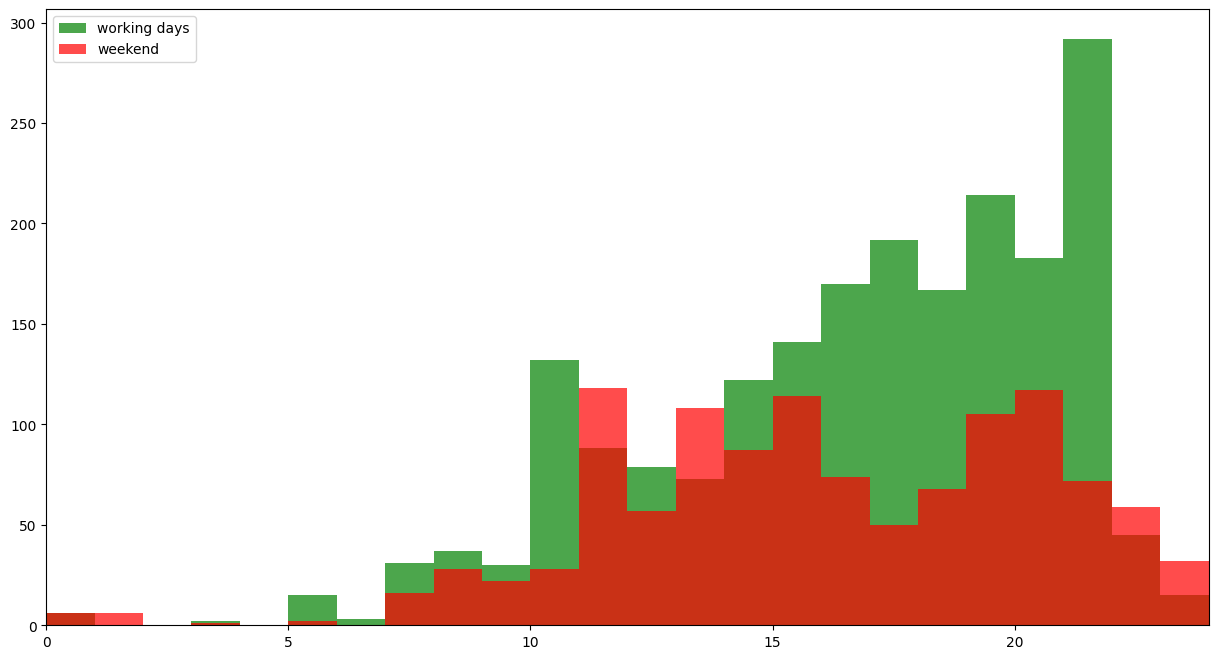

In [4]:
plt.rcParams["figure.figsize"] = (15, 8)
ax1 = plt.bar(range(24), working_days, label="working days", align="edge", width=1, color="green", alpha=0.7)
ax2 = plt.bar(range(24), weekends, label="weekend", align="edge", width=1, color="red", alpha=0.7)

plt.xlim(0, 24)
plt.legend()
plt.show()

In [5]:
conn.close()

Вопросы:

Были ли случаи, когда общее количество коммитов в выходные дни превышало количество коммитов в рабочие дни? 
Ответ: Да, в 11, 13, 22 и 23